# DS4FE — SPX Implied-Volatility Surfaces: PCA vs Nonlinear DR (v1)

**Motivation.** The raw 20-D LOB study showed nonlinear DR adds little: the data has no clean low-D manifold, so PCA wins for compression. We pivot to a dataset where low-dimensional structure is *expected by theory*: the **SPX implied-volatility surface**.

An IV surface is known to be driven by ~3 factors (**level / skew / curvature**) and is constrained by **no-arbitrage**, which curves the space of valid surfaces. That curvature is exactly what nonlinear methods (ISOMAP) are built to capture.

**Research question.** Does the SPX IV surface live on a low-dimensional manifold, and does ISOMAP capture it better than PCA — especially across vol regimes (calm 2021 → 2022 selloff → 2023 recovery)?

**Data.** Databento `OPRA.PILLAR` SPX options, 15:45-ET snapshot, 2021-06 to 2023-06. IV computed by us via Black-76 (SPX is European); forward/rate per expiry from put-call parity. Each day → one surface on a fixed 7×9 (maturity × moneyness) grid.

## One-picture takeaway

![IV surface vs LOB takeaway](figures/iv_surface_takeaway.svg)

**Plain-English reading:** Across *both* datasets, nonlinear DR (ISOMAP) does not beat PCA — but for opposite reasons. Raw LOB has no clean low-dimensional manifold (intrinsic dim ~9–10, too noisy). The IV surface *does* have a clean low-dimensional manifold (intrinsic dim ~3.8), but it is **linear** (3 PCA factors capture ~99%), so there is no curvature left for ISOMAP to exploit. When low-D structure exists in these financial datasets, it is linear → **PCA is the right tool.**

## Section 0 — Setup + load surfaces

In [1]:
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr

IV_DIR = pathlib.Path('data/iv')
FIG = pathlib.Path('figures/iv'); FIG.mkdir(parents=True, exist_ok=True)

surf = pd.read_parquet(IV_DIR / 'surfaces.parquet').sort_index()
grid = json.load(open(IV_DIR / 'surface_grid.json'))
MATS, MONEY = np.array(grid['mats_days']), np.array(grid['moneyness'])
print('surfaces:', surf.shape, '| dates:', surf.index.min().date(), '->', surf.index.max().date())
surf.head()

surfaces: (523, 63) | dates: 2021-06-01 -> 2023-06-30


,T30_m850,T30_m900,T30_m950,T30_m975,T30_m1000,T30_m1025,T30_m1050,T30_m1100,T30_m1150,T60_m850,...,T273_m1150,T365_m850,T365_m900,T365_m950,T365_m975,T365_m1000,T365_m1025,T365_m1050,T365_m1100,T365_m1150
date,,,,,,,,,,,,,,,,,,,,,
2021-06-01,0.314765,0.254982,0.197106,0.166272,0.136394,0.115262,0.111606,0.134205,0.170407,0.283585,...,0.133775,0.245173,0.225337,0.204875,0.194514,0.184137,0.173856,0.164139,0.148580,0.139961
2021-06-02,0.308860,0.249611,0.191904,0.161366,0.131385,0.110481,0.108789,0.142108,0.187173,0.281549,...,0.133984,0.246549,0.226874,0.206522,0.196141,0.185746,0.175456,0.165637,0.149694,0.140729
2021-06-03,0.314594,0.252582,0.195346,0.165968,0.136426,0.114578,0.106908,0.127357,0.147796,0.285354,...,0.135584,0.249544,0.229707,0.209242,0.198849,0.188404,0.178011,0.168066,0.151780,0.142485
2021-06-04,0.297738,0.240456,0.181575,0.152040,0.123263,0.104189,0.103732,0.139484,0.185605,0.273413,...,0.132111,0.245417,0.225491,0.204840,0.194310,0.183794,0.173532,0.163780,0.148083,0.139284
2021-06-07,0.304340,0.242005,0.183453,0.153894,0.125082,0.105555,0.103854,0.120928,0.154576,0.275580,...,0.132747,0.245713,0.225859,0.205445,0.194986,0.184643,0.174268,0.164557,0.148562,0.139734


## Section 1 — What a surface looks like (calm vs stress)

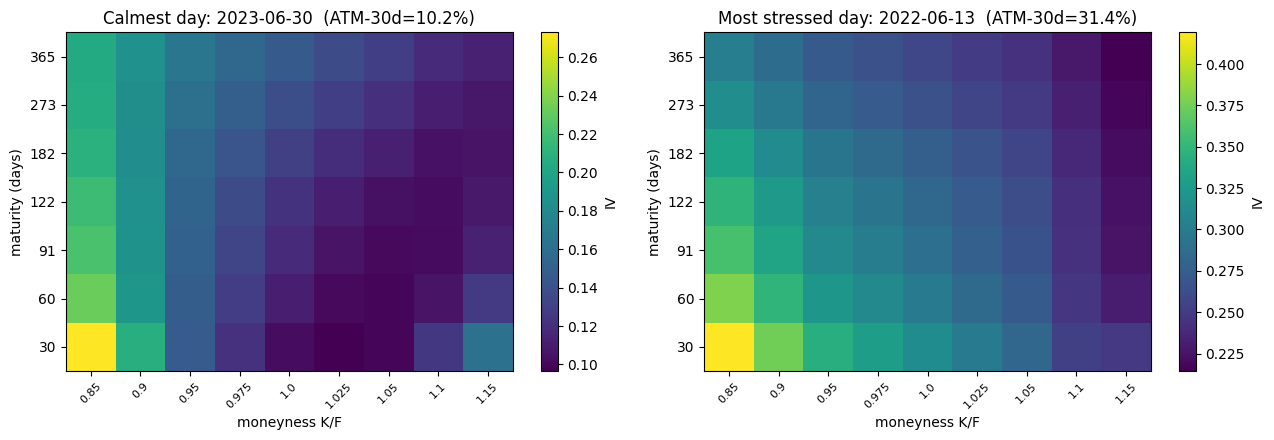

In [2]:
atm = surf[[c for c in surf.columns if c.endswith('_m1000')]]
atm30 = surf['T30_m1000']
calm_day = atm30.idxmin(); stress_day = atm30.idxmax()

def as_grid(row):
    return row.values.reshape(len(MATS), len(MONEY))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, day, title in [(axes[0], calm_day, 'Calmest day'), (axes[1], stress_day, 'Most stressed day')]:
    im = ax.imshow(as_grid(surf.loc[day]), aspect='auto', origin='lower', cmap='viridis')
    ax.set_xticks(range(len(MONEY))); ax.set_xticklabels(MONEY, rotation=45, fontsize=8)
    ax.set_yticks(range(len(MATS))); ax.set_yticklabels(MATS)
    ax.set_xlabel('moneyness K/F'); ax.set_ylabel('maturity (days)')
    ax.set_title(f'{title}: {day.date()}  (ATM-30d={atm30.loc[day]:.1%})')
    plt.colorbar(im, ax=ax, label='IV')
plt.tight_layout(); plt.savefig(FIG / 'example_surfaces.png', dpi=130); plt.show()

## Section 2 — Regime indicator (ATM-30d IV over time)
Used later to colour the embeddings. This is our proxy for the vol regime.

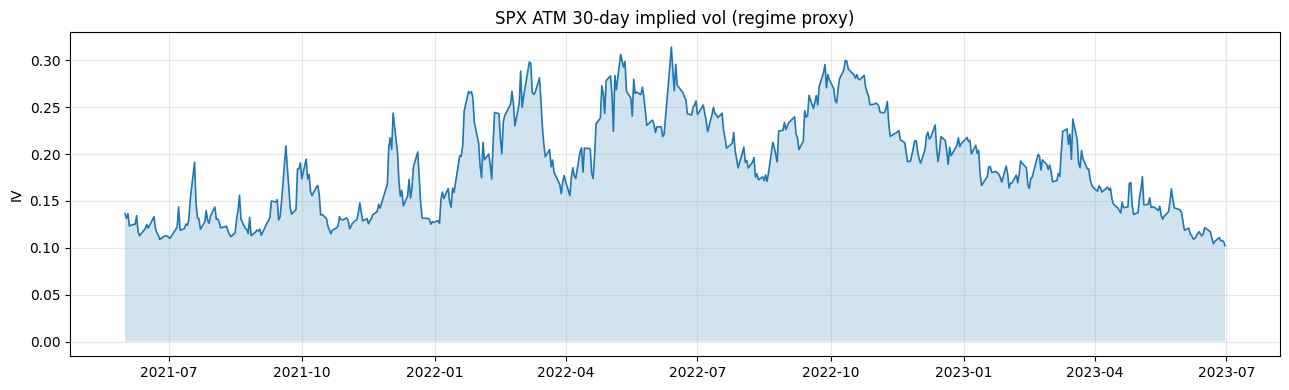

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(atm30.index, atm30.values, lw=1.2)
ax.fill_between(atm30.index, atm30.values, alpha=0.2)
ax.set_title('SPX ATM 30-day implied vol (regime proxy)')
ax.set_ylabel('IV'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'regime_atm30.png', dpi=130); plt.show()

## Section 3 — PCA: how few factors explain the surface?

explained variance ratio (first 5): [0.9259 0.0451 0.018  0.0059 0.0023]
cumulative (first 3): [0.9259 0.971  0.989 ]


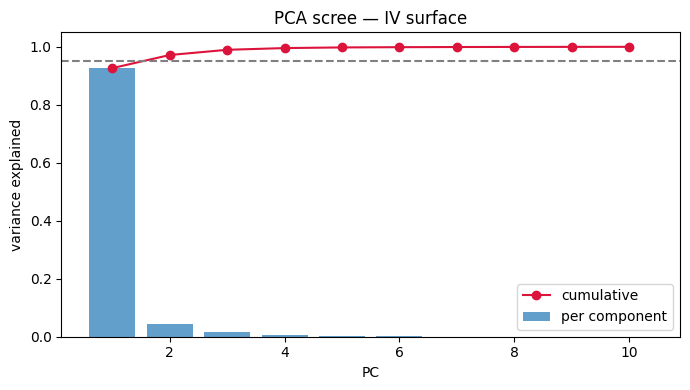

In [4]:
X = surf.values
Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=10, svd_solver='full').fit(Xs)
evr = pca.explained_variance_ratio_
print('explained variance ratio (first 5):', np.round(evr[:5], 4))
print('cumulative (first 3):', np.round(np.cumsum(evr)[:3], 4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 11), evr, alpha=0.7, label='per component')
ax.plot(range(1, 11), np.cumsum(evr), 'o-', color='crimson', label='cumulative')
ax.axhline(0.95, ls='--', color='gray'); ax.set_xlabel('PC'); ax.set_ylabel('variance explained')
ax.legend(); ax.set_title('PCA scree \u2014 IV surface'); plt.tight_layout()
plt.savefig(FIG / 'pca_scree.png', dpi=130); plt.show()

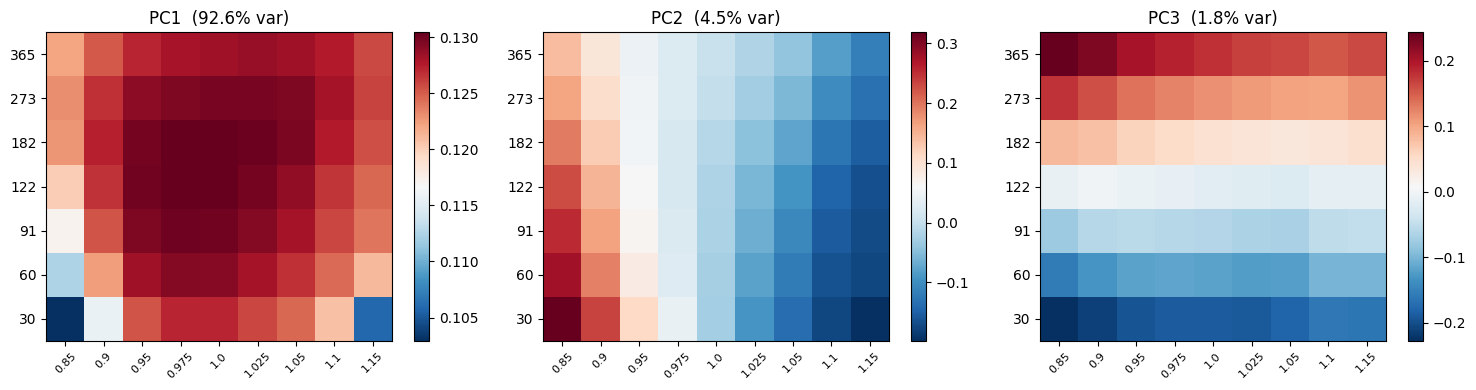

In [5]:
# First 3 PCA loadings reshaped as surfaces -> interpret as level / skew / curvature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, ax in enumerate(axes):
    L = pca.components_[k].reshape(len(MATS), len(MONEY))
    im = ax.imshow(L, aspect='auto', origin='lower', cmap='RdBu_r')
    ax.set_xticks(range(len(MONEY))); ax.set_xticklabels(MONEY, rotation=45, fontsize=8)
    ax.set_yticks(range(len(MATS))); ax.set_yticklabels(MATS)
    ax.set_title(f'PC{k+1}  ({evr[k]:.1%} var)'); plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.savefig(FIG / 'pca_loadings.png', dpi=130); plt.show()

## Section 4 — PCA-2 vs ISOMAP-2: geometry + reconstruction

/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


PCA-2   rho_self = 0.9983
ISOMAP-2 rho_self = 0.9891


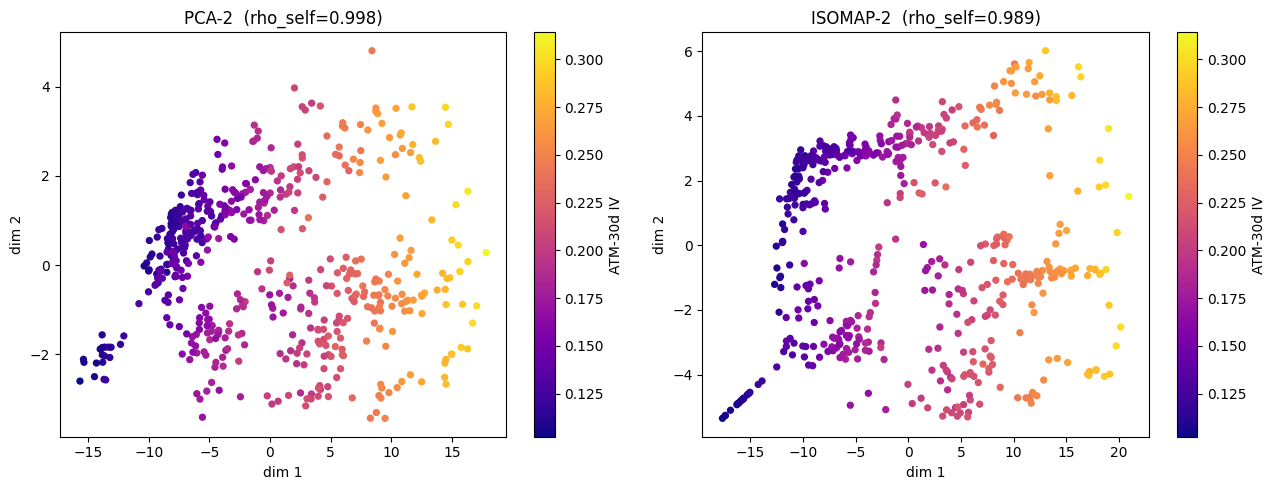

In [6]:
D = pairwise_distances(Xs)
iu = np.triu_indices_from(D, k=1)
d_hi = D[iu]

def rho_self(emb):
    de = pairwise_distances(emb)[iu]
    return spearmanr(d_hi, de).statistic

pca2 = PCA(n_components=2, svd_solver='full').fit_transform(Xs)
iso2 = Isomap(n_neighbors=10, n_components=2).fit_transform(Xs)

print(f'PCA-2   rho_self = {rho_self(pca2):.4f}')
print(f'ISOMAP-2 rho_self = {rho_self(iso2):.4f}')

c = atm30.values
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, emb, name in [(axes[0], pca2, 'PCA-2'), (axes[1], iso2, 'ISOMAP-2')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=c, cmap='plasma', s=18)
    ax.set_title(f'{name}  (rho_self={rho_self(emb):.3f})'); ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
    plt.colorbar(sc, ax=ax, label='ATM-30d IV')
plt.tight_layout(); plt.savefig(FIG / 'pca_vs_isomap.png', dpi=130); plt.show()

## Section 5 — Intrinsic dimension (TwoNN)

In [7]:
def twonn(Xin):
    Dm = pairwise_distances(Xin); Dm.sort(axis=1)
    r1, r2 = Dm[:, 1], Dm[:, 2]
    mask = r1 > 0
    mu = np.sort((r2[mask] / r1[mask]))
    F = np.arange(1, len(mu) + 1) / len(mu)
    x, y = np.log(mu), -np.log(1 - F + 1e-12)
    keep = slice(0, int(0.9 * len(x)))
    d = np.linalg.lstsq(x[keep, None], y[keep], rcond=None)[0][0]
    return d

print(f'TwoNN intrinsic dimension (standardized surface): {twonn(Xs):.2f}')
print(f'TwoNN on raw surface:                              {twonn(X):.2f}')

TwoNN intrinsic dimension (standardized surface): 3.76
TwoNN on raw surface:                              3.76


/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/harold/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Section 6 — Verdict

**Dataset:** 523 daily SPX IV surfaces (2021-06 → 2023-06), 63-point grid (7 maturities × 9 moneyness).

**Findings:**

- **The IV surface IS genuinely low-dimensional.** TwoNN intrinsic dimension ≈ **3.76** — close to the textbook 3 factors (level / skew / curvature), and *far* lower than the ~9–10 we measured for raw 20-D LOB.
- **3 PCA factors explain 98.9% of variance** (PC1=92.6% level, PC2=4.5% skew, PC3=1.8% curvature). The scree and loading plots confirm the classic interpretation.
- **But the structure is essentially *linear*.** PCA-2 preserves **99.8%** of pairwise geometry (`rho_self=0.9983`), and **ISOMAP-2 does NOT beat it** (`rho_self=0.9891`).

**Conclusion — a clean unified story across both datasets:**

> Nonlinear DR (ISOMAP) adds nothing for *either* dataset, but for opposite reasons.
> - **Raw LOB:** PCA wins because the data is high-dimensional and noisy — there is no clean low-D manifold to exploit (intrinsic dim ~9–10).
> - **IV surface:** PCA wins because the manifold is low-dimensional *and linear* — 3 linear factors already capture ~99% of it, leaving no curvature for ISOMAP to recover (intrinsic dim ~3.8).

So for these financial datasets, **when low-dimensional structure exists, it is linear**, and PCA is the right tool. Nonlinear methods would only help if there were genuine curvature that PCA misses — which we do not find here.